In [1]:
from huggingface_hub.cli.datasets import datasets_cli
!pip install -q sentence-transformers scikit-learn pandas numpy matplotlib seaborn joblib

Imports

In [5]:
import os
import random
import json
import numpy as np
import pandas as pd

# Hugging Face Datasets
from datasets import load_dataset, Dataset, concatenate_datasets

# Sentence Transformers
from sentence_transformers import SentenceTransformer

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Saving models
import joblib


# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("✅ All imports successful.")
print("Hugging Face load_dataset:", load_dataset)

✅ All imports successful.
Hugging Face load_dataset: <function load_dataset at 0x7f327b65aac0>


Configuration

In [6]:
SAMPLES_PER_DOMAIN = 2500

MATH_DATASET = "meta-math/MetaMathQA"
CODE_DATASET = "nickrosh/Evol-Instruct-Code-80k-v1"
CREATIVE_DATASET = "euclaise/writingprompts"

ROUTER_DIR = "./router_model"

os.makedirs(ROUTER_DIR, exist_ok=True)

print("✅ Configuration loaded.")

✅ Configuration loaded.


Loading datasets

In [7]:
#MATH
print("Loading Math dataset...")

math_raw = load_dataset(
    MATH_DATASET,
    split="train"
)

print(math_raw)
print("Number of Math examples:", len(math_raw))
print("Columns:", math_raw.column_names)

Loading Math dataset...


README.md: 0.00B [00:00, ?B/s]

MetaMathQA-395K.json:   0%|          | 0.00/396M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/395000 [00:00<?, ? examples/s]

Dataset({
    features: ['type', 'query', 'original_question', 'response'],
    num_rows: 395000
})
Number of Math examples: 395000
Columns: ['type', 'query', 'original_question', 'response']


In [8]:
#CODE
print("Loading Code dataset...")

code_raw = load_dataset(
    CODE_DATASET,
    split="train"
)

print(code_raw)
print("Number of Code examples:", len(code_raw))
print("Columns:", code_raw.column_names)

Loading Code dataset...


README.md:   0%|          | 0.00/282 [00:00<?, ?B/s]

EvolInstruct-Code-80k.json:   0%|          | 0.00/121M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/78264 [00:00<?, ? examples/s]

Dataset({
    features: ['instruction', 'output'],
    num_rows: 78264
})
Number of Code examples: 78264
Columns: ['instruction', 'output']


In [9]:
#WRITING
print("Loading Creative dataset...")

creative_raw = load_dataset(
    CREATIVE_DATASET,
    split="train"
)

print(creative_raw)
print("Number of Creative examples:", len(creative_raw))
print("Columns:", creative_raw.column_names)

Loading Creative dataset...


README.md:   0%|          | 0.00/837 [00:00<?, ?B/s]

data/train-00000-of-00002-105e07cb0d1994(…):   0%|          | 0.00/272M [00:00<?, ?B/s]

data/train-00001-of-00002-4fdb982c110564(…):   0%|          | 0.00/272M [00:00<?, ?B/s]

data/test-00000-of-00001-16503b0c26ed00c(…):   0%|          | 0.00/30.0M [00:00<?, ?B/s]

data/validation-00000-of-00001-137b93e1e(…):   0%|          | 0.00/30.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/272600 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/15138 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/15620 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'story'],
    num_rows: 272600
})
Number of Creative examples: 272600
Columns: ['prompt', 'story']


inspecting the data sets

In [10]:
print("========== MATH ==========")
print(math_raw[0])

print("\n========== CODE ==========")
print(code_raw[0])

print("\n========== CREATIVE ==========")
print(creative_raw[0])

========== MATH ==========
{'type': 'MATH_AnsAug', 'query': "Gracie and Joe are choosing numbers on the complex plane. Joe chooses the point $1+2i$. Gracie chooses $-1+i$. How far apart are Gracie and Joe's points?", 'original_question': "Gracie and Joe are choosing numbers on the complex plane. Joe chooses the point $1+2i$. Gracie chooses $-1+i$. How far apart are Gracie and Joe's points?", 'response': "The distance between two points $(x_1,y_1)$ and $(x_2,y_2)$ in the complex plane is given by the formula $\\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}$.\nIn this case, Joe's point is $(1,2)$ and Gracie's point is $(-1,1)$.\nSo the distance between their points is $\\sqrt{((-1)-(1))^2+((1)-(2))^2}=\\sqrt{(-2)^2+(-1)^2}=\\sqrt{4+1}=\\sqrt{5}$.\nTherefore, Gracie and Joe's points are $\\boxed{\\sqrt{5}}$ units apart.\nThe answer is: \\sqrt{5}"}

========== CODE ==========
{'instruction': 'Create a nested loop to print every combination of numbers between 0-9, excluding any combination that contains th

In [12]:
def extract_math_query(example):
    """
    Extract the user-side mathematical instruction.
    MetaMathQA commonly uses:
        query
        response
    """
    return example["query"]


def extract_code_query(example):
    """
    Extract the user-side coding instruction.

    Evol-Instruct-Code datasets can expose the instruction
    under different column names, so handle the common cases.
    """
    for key in ["instruction", "prompt", "question", "input"]:
        if key in example and example[key]:
            return example[key]

    raise KeyError(
        f"Could not find a query column in Code example. "
        f"Available columns: {list(example.keys())}"
    )


def extract_creative_query(example):
    """
    WritingPrompts uses the writing prompt as the user query.
    """
    for key in ["prompt", "text"]:
        if key in example and example[key]:
            return example[key]

    raise KeyError(
        f"Could not find a prompt column in Creative example. "
        f"Available columns: {list(example.keys())}"
    )

In [13]:
math_queries = []

for example in math_raw:
    try:
        query = extract_math_query(example)

        if query and isinstance(query, str):
            query = query.strip()

            if len(query) >= 10:
                math_queries.append(query)

    except Exception:
        continue


print("Valid Math queries:", len(math_queries))
print("\nExample:")
print(math_queries[0])

Valid Math queries: 394996

Example:
Gracie and Joe are choosing numbers on the complex plane. Joe chooses the point $1+2i$. Gracie chooses $-1+i$. How far apart are Gracie and Joe's points?


In [14]:
code_queries = []

for example in code_raw:
    try:
        query = extract_code_query(example)

        if query and isinstance(query, str):
            query = query.strip()

            if len(query) >= 10:
                code_queries.append(query)

    except Exception:
        continue


print("Valid Code queries:", len(code_queries))
print("\nExample:")
print(code_queries[0])

Valid Code queries: 78264

Example:
Create a nested loop to print every combination of numbers between 0-9, excluding any combination that contains the number 5. Additionally, exclude any combination that contains a repeating digit. Implement the solution without using any built-in functions or libraries to check for repeating digits.


In [15]:
creative_queries = []

for example in creative_raw:
    try:
        query = extract_creative_query(example)

        if query and isinstance(query, str):
            query = query.strip()

            if len(query) >= 10:
                creative_queries.append(query)

    except Exception:
        continue


print("Valid Creative queries:", len(creative_queries))
print("\nExample:")
print(creative_queries[0])

Valid Creative queries: 272577

Example:
[ WP ] You 've finally managed to discover the secret to immortality . Suddenly , Death appears before you , hands you a business card , and says , `` When you realize living forever sucks , call this number , I 've got a job offer for you . ''


Remove Duplicates

In [16]:
def clean_queries(queries):
    queries = [
        q.strip()
        for q in queries
        if isinstance(q, str) and q.strip()
    ]

    return list(dict.fromkeys(queries))


math_queries = clean_queries(math_queries)
code_queries = clean_queries(code_queries)
creative_queries = clean_queries(creative_queries)

print("After deduplication:")
print("Math     :", len(math_queries))
print("Code     :", len(code_queries))
print("Creative :", len(creative_queries))

After deduplication:
Math     : 146115
Code     : 78150
Creative : 97343


Random Sampling the dataset

In [17]:
rng = random.Random(SEED)

math_sample = rng.sample(
    math_queries,
    min(SAMPLES_PER_DOMAIN, len(math_queries))
)

code_sample = rng.sample(
    code_queries,
    min(SAMPLES_PER_DOMAIN, len(code_queries))
)

creative_sample = rng.sample(
    creative_queries,
    min(SAMPLES_PER_DOMAIN, len(creative_queries))
)

router_df = pd.DataFrame({
    "query": (
        math_sample +
        code_sample +
        creative_sample
    ),
    "label": (
        ["math"] * len(math_sample) +
        ["code"] * len(code_sample) +
        ["creative"] * len(creative_sample)
    )
})

router_df = router_df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print(router_df.shape)
print()
print(router_df["label"].value_counts())

(7500, 2)

label
math        2500
creative    2500
code        2500
Name: count, dtype: int64


In [18]:
#Inspecting
pd.set_option(
    "display.max_colwidth",
    300
)

router_df.sample(
    15,
    random_state=SEED
)

,query,label
970,Name the parameter of a Python function?,code
6279,Suggest a completion for the following HTML code to demonstrate items in a nested unordered list. The nested list should have two levels of indentation.\n<ul>\n <li>\n Item 1\n <ul>\n <li>Subitem 1</li>\n <li>Subitem 2</li>\n </ul>\n </li>\n <l...,code
1859,"Create a while loop in JavaScript that reverses an array and prints each element to the console. The array to be reversed is [""apple"", ""banana"", ""orange"", ""grape""]. However, you are not allowed to use any built-in array manipulation methods such as reverse() or sort().\n\nAdditionally, you are n...",code
6803,"[ WP ] Your ear starts ringing intensely and your body goes limp . Next thing you know you 're walking toward the door , but you 're not controlling your own movement .",creative
6305,"Retrieve the third item from a doubly linked list, delete it from the list, and then insert it at the end of the list.",code
3039,Edit the following HTML to link the page with a stylesheet\n<!DOCTYPE html>\n<html>\n<head>\n <title>My Page</title>\n</head>\n<body>\n\n</body>\n</html>,code
7194,"If the price of a home is $98 per square foot (sq ft), and the house is 2,400 sq ft and the barn is 1,000 sq ft, what is the total value of the property?",math
1446,"Modify the code to display a simple error message whenever a parameter is passed as string. Additionally, ensure that the function only accepts numerical values for the parameters. The function should throw an error if either parameter is not a number.\nfunction sum(a, b) {\n if (typeof a !== '...",code
5199,"Create a function to generate a random string with the given length, where the string should contain at least one uppercase letter, one lowercase letter, and one special character. Length = 10",code
6234,"What is the total cost of all the beads that Carly bought for her beaded corset, considering she will add 50 rows of purple beads with 20 beads per row, 40 rows of blue beads with 18 beads per row, and 80 gold beads, and that beads cost $1 per 10 beads?",math


Train Test Split

In [19]:
X = router_df["query"].values
y = router_df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training:", len(X_train))
print("Testing :", len(X_test))

print("\nTraining distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting distribution:")
print(pd.Series(y_test).value_counts())

Training: 6000
Testing : 1500

Training distribution:
math        2000
code        2000
creative    2000
Name: count, dtype: int64

Testing distribution:
code        500
creative    500
math        500
Name: count, dtype: int64


Load SentenceTransformer

In [20]:
EMBEDDING_MODEL_NAME = (
    "sentence-transformers/all-MiniLM-L6-v2"
)

embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_NAME
)

print("Embedding model:", EMBEDDING_MODEL_NAME)
print(
    "Embedding dimension:",
    embedding_model.get_sentence_embedding_dimension()
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model: sentence-transformers/all-MiniLM-L6-v2
Embedding dimension: 384


/tmp/ipykernel_58/1438458283.py:12: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embedding_model.get_sentence_embedding_dimension()


Generate embeddings efficiently

In [21]:
print("Encoding training queries...")

X_train_embeddings = embedding_model.encode(
    X_train,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True
)

print(
    "Training embeddings:",
    X_train_embeddings.shape
)

Encoding training queries...


Batches:   0%|          | 0/94 [00:00<?, ?it/s]

Training embeddings: (6000, 384)


Encode test queries

In [22]:
print("Encoding test queries...")

X_test_embeddings = embedding_model.encode(
    X_test,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True
)

print(
    "Test embeddings:",
    X_test_embeddings.shape
)

Encoding test queries...


Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Test embeddings: (1500, 384)


Train the logistic regression

In [23]:
router_classifier = LogisticRegression(
    max_iter=1000,
    random_state=SEED,
    class_weight="balanced"
)

router_classifier.fit(
    X_train_embeddings,
    y_train
)

print("Router training complete.")
print("Classes:", router_classifier.classes_)

Router training complete.
Classes: ['code' 'creative' 'math']


Evaluate

In [24]:
y_pred = router_classifier.predict(
    X_test_embeddings
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Macro F1 : {macro_f1 * 100:.2f}%")

Accuracy : 99.20%
Macro F1 : 99.20%


In [25]:
#REPORT
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

        code     0.9880    0.9880    0.9880       500
    creative     0.9940    0.9940    0.9940       500
        math     0.9940    0.9940    0.9940       500

    accuracy                         0.9920      1500
   macro avg     0.9920    0.9920    0.9920      1500
weighted avg     0.9920    0.9920    0.9920      1500



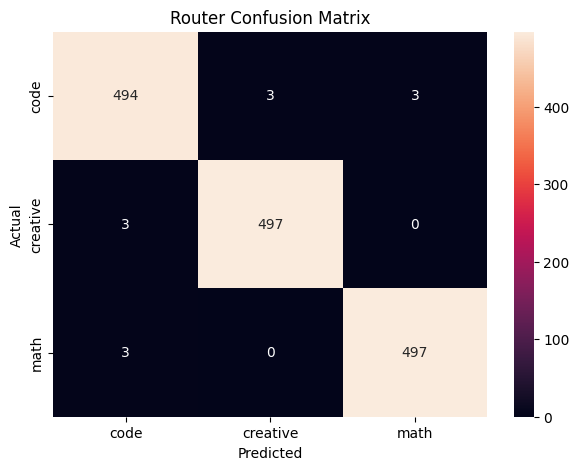

In [26]:
#Confusion Matrix
labels = router_classifier.classes_

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Router Confusion Matrix")

plt.show()

Inspecting routernet mistakes

In [27]:
results_df = pd.DataFrame({
    "query": X_test,
    "actual": y_test,
    "predicted": y_pred
})

incorrect = results_df[
    results_df["actual"] != results_df["predicted"]
].copy()

print(
    f"Incorrect predictions: {len(incorrect)}"
)

incorrect.head(30)

Incorrect predictions: 12


,query,actual,predicted
102,Compute the sum of the squares of all the numbers between 1 and 10 (inclusively).,code,math
234,Generate a working React component to parse GEDCOM data.,code,creative
355,"Parse the sentence and extract all the verbs from it.\nSentence: ""She ran quickly to catch the bus.""",code,creative
619,Just be yourself ...,creative,code
651,Create a linux shell script for restarting network interfaces.,code,creative
700,"The double-bar graph shows the number of home runs hit by McGwire and Sosa during each month of the 1998 baseball season. At the end of which month were McGwire and Sosa tied in total number of home runs?\n\n[asy]\ndraw((0,0)--(28,0)--(28,21)--(0,21)--(0,0)--cycle,linewidth(1));\n\nfor(int i = 1...",math,code
848,"Find the GCD of two integers using the Euclidean algorithm.\na = 8, b = 12",code,math
928,"[ WP ] Your initial Amazon review for a product is 1 star . In the weeks following , you 're compelled to periodically update your review , adding stars one-by-one , until you 've given the product a perfect rating .",creative,code
966,Calculate the value of $\#(\#(\#50))$ where $\#N$ is defined by the formula $\#N = .5(N) + 1$.,math,code
1232,[ PM ] I 'm nearing the end of my semester at college and I want to keep writing through the summer .,creative,code


Confidence scores

In [28]:
probabilities = router_classifier.predict_proba(
    X_test_embeddings
)

results_df["confidence"] = probabilities.max(
    axis=1
)

results_df.sort_values(
    "confidence"
).head(30)

,query,actual,predicted,confidence
1449,What is the simplified form of $(2x^3)^3$?,math,code,0.459242
925,[ WP ] It is the year 2573 . The word antibiotic has taken on a brand new meaning in the last 100 years .,creative,creative,0.460099
1232,[ PM ] I 'm nearing the end of my semester at college and I want to keep writing through the summer .,creative,code,0.503254
651,Create a linux shell script for restarting network interfaces.,code,creative,0.514294
234,Generate a working React component to parse GEDCOM data.,code,creative,0.521477
1048,Output the factorial of 7,code,code,0.528577
525,"Suppose that there exist nonzero complex numbers $a,$ $b,$ $c,$ and $d$ such that $k$ is a root of both the equations $ax^3 + bx^2 + cx + d = 0$ and $bx^3 + cx^2 + dx + a = 0.$ Enter all possible values of $k,$ separated by commas.",math,math,0.533261
1367,How does the fadeIn() function work in jQuery?,code,code,0.536308
919,Explain the purpose of the keyword ``this`` in Java and provide an example of its usage in a class constructor.,code,code,0.539324
860,"Let $x$ and $y$ be nonzero real numbers. Let $m$ and $M$ be the minimium value and maximum value of\n\[\frac{|x + y|}{|x| + |y|},\]respectively. Find $M - m.$",math,math,0.559686


Reusable Router Function

In [29]:
def classify_query(query):
    """
    Predict the domain of a user query.

    Returns:
        domain
        confidence
        probabilities
    """

    embedding = embedding_model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True
    )

    probabilities = router_classifier.predict_proba(
        embedding
    )[0]

    index = np.argmax(probabilities)

    domain = router_classifier.classes_[index]
    confidence = probabilities[index]

    return {
        "domain": domain,
        "confidence": float(confidence),
        "probabilities": {
            cls: float(prob)
            for cls, prob in zip(
                router_classifier.classes_,
                probabilities
            )
        }
    }


print("Router inference function ready.")

Router inference function ready.


Test with real unseen-style queries

In [30]:
test_queries = [
    "What is the probability of getting at least two sixes when rolling a die five times?",

    "Can you optimize this algorithm so that it works efficiently for one million elements?",

    "Write a scene where two people meet again after believing the other had died.",

    "Find the eigenvalues of the following matrix and explain the calculation.",

    "Implement a function that detects whether a linked list contains a cycle.",

    "Describe a world where memories can be bought and sold."
]

for query in test_queries:

    result = classify_query(query)

    print("=" * 80)
    print("Query:", query)
    print("Domain:", result["domain"].upper())
    print(
        "Confidence:",
        f"{result['confidence'] * 100:.2f}%"
    )
    print("Probabilities:", result["probabilities"])

Query: What is the probability of getting at least two sixes when rolling a die five times?
Domain: MATH
Confidence: 79.71%
Probabilities: {'code': 0.14859132229984057, 'creative': 0.05431134572790136, 'math': 0.7970973319722581}
Query: Can you optimize this algorithm so that it works efficiently for one million elements?
Domain: CODE
Confidence: 99.22%
Probabilities: {'code': 0.992164991038484, 'creative': 0.003661598546166728, 'math': 0.004173410415349213}
Query: Write a scene where two people meet again after believing the other had died.
Domain: CREATIVE
Confidence: 98.95%
Probabilities: {'code': 0.007055127190997205, 'creative': 0.9894942849444868, 'math': 0.0034505878645161026}
Query: Find the eigenvalues of the following matrix and explain the calculation.
Domain: MATH
Confidence: 86.36%
Probabilities: {'code': 0.10827756620877814, 'creative': 0.028083284525051863, 'math': 0.86363914926617}
Query: Implement a function that detects whether a linked list contains a cycle.
Domain: 

Save the router

In [31]:
joblib.dump(
    router_classifier,
    os.path.join(
        ROUTER_DIR,
        "logistic_router.pkl"
    )
)

embedding_model.save(
    os.path.join(
        ROUTER_DIR,
        "embedding_model"
    )
)

print("Router saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Router saved successfully.


Save metadata

In [32]:
metadata = {
    "embedding_model": EMBEDDING_MODEL_NAME,
    "classifier": "LogisticRegression",
    "classes": router_classifier.classes_.tolist(),
    "seed": SEED,
    "samples_per_domain": SAMPLES_PER_DOMAIN,
    "train_samples": len(X_train),
    "test_samples": len(X_test),
    "accuracy": float(accuracy),
    "macro_f1": float(macro_f1)
}

with open(
    os.path.join(
        ROUTER_DIR,
        "metadata.json"
    ),
    "w"
) as f:
    json.dump(
        metadata,
        f,
        indent=4
    )

print(json.dumps(metadata, indent=4))

{
    "embedding_model": "sentence-transformers/all-MiniLM-L6-v2",
    "classifier": "LogisticRegression",
    "classes": [
        "code",
        "creative",
        "math"
    ],
    "seed": 42,
    "samples_per_domain": 2500,
    "train_samples": 6000,
    "test_samples": 1500,
    "accuracy": 0.992,
    "macro_f1": 0.992
}


Save the exact router dataset

In [33]:
router_df.to_csv(
    os.path.join(
        ROUTER_DIR,
        "router_dataset.csv"
    ),
    index=False
)

print(
    "Saved:",
    os.path.join(
        ROUTER_DIR,
        "router_dataset.csv"
    )
)

Saved: ./router_model/router_dataset.csv


Rigouros Training

In [34]:
# ============================================================
# FROZEN ROUTER TEST
# Cell 1 — Identify training samples
# ============================================================

# router_df contains the samples used to train/test the router
training_queries = set(router_df["query"].tolist())

print("Queries used by router:", len(training_queries))

Queries used by router: 7500


In [35]:
# ============================================================
# Cell 2 — Remove ALL previously used queries
# ============================================================

unused_math = [
    q for q in math_queries
    if q not in training_queries
]

unused_code = [
    q for q in code_queries
    if q not in training_queries
]

unused_creative = [
    q for q in creative_queries
    if q not in training_queries
]

print("Unused Math queries     :", len(unused_math))
print("Unused Code queries     :", len(unused_code))
print("Unused Creative queries:", len(unused_creative))

Unused Math queries     : 143615
Unused Code queries     : 75650
Unused Creative queries: 94843


In [37]:
# ============================================================
# Cell 3 — Select completely unseen samples
# ============================================================

TEST_SEED = 2026
rng = random.Random(TEST_SEED)

N_TEST = 1000

test_math = rng.sample(
    unused_math,
    min(N_TEST, len(unused_math))
)

test_code = rng.sample(
    unused_code,
    min(N_TEST, len(unused_code))
)

test_creative = rng.sample(
    unused_creative,
    min(N_TEST, len(unused_creative))
)

unseen_test_df = pd.DataFrame({
    "query": (
        test_math +
        test_code +
        test_creative
    ),
    "actual": (
        ["math"] * len(test_math) +
        ["code"] * len(test_code) +
        ["creative"] * len(test_creative)
    )
})

unseen_test_df = unseen_test_df.sample(
    frac=1,
    random_state=TEST_SEED
).reset_index(drop=True)

print("Total unseen samples:", len(unseen_test_df))
print()
print(unseen_test_df["actual"].value_counts())

Total unseen samples: 3000

actual
math        1000
creative    1000
code        1000
Name: count, dtype: int64


In [38]:
# ============================================================
# Cell 4 — Verify there is absolutely no overlap
# ============================================================

overlap = (
    set(unseen_test_df["query"]) &
    training_queries
)

print("Training samples :", len(training_queries))
print("New test samples :", len(unseen_test_df))
print("Overlap          :", len(overlap))

if len(overlap) == 0:
    print("\n✅ PERFECT — ZERO OVERLAP")
else:
    print("\n❌ OVERLAP FOUND")
    print("Examples:")
    for q in list(overlap)[:10]:
        print("-", q)

Training samples : 7500
New test samples : 3000
Overlap          : 0

✅ PERFECT — ZERO OVERLAP


In [39]:
# ============================================================
# Cell 5 — Inspect unseen samples
# ============================================================

pd.set_option(
    "display.max_colwidth",
    300
)

unseen_test_df.sample(
    30,
    random_state=TEST_SEED
)

,query,actual
146,"What is the area, in square units, of a triangle with side lengths of 8, 15, and 17 units?",math
935,"Develop a program to generate a random integer from 1 to 100 and store it in an array. Then, sort the array in ascending order using any sorting algorithm of your choice. Finally, output the sorted array.",code
11,[ WP ] Instead of the `` No child left behind “ law there is now a “ No child goes ahead ” law where if one person fails in your class all of the students are held back .,creative
2450,"Matilda has x% as many jellybeans as Matt. Matt has ten times as many jellybeans as Steve. If Steve has 84 jellybeans, Matilda has 420 jellybeans. What is the value of unknown variable x? What is the value of unknown variable x?",math
1055,Tracy has a charity book collection store from which she receives book donations from members of her town. Any person who wants to borrow a book is free to do so as long as they return the book after they've finished reading. She has already received 300 book donations. If x people come and dona...,math
2476,"Write a stored procedure in MySQL to subtract two numbers, where the numbers should be greater than zero, should not exceed 1000, and should be prime numbers.",code
2688,[ CW ] A man sits alone in a graveyard ...,creative
754,"[ WP ] You are a totally original character and definitely not an overpowered lawsuit-waiting-to-happen mix of all the cool aspects , costumes and powers of your favourite existing superheroes .",creative
2177,"[ WP ] `` Do n't worry , I can drive . ''",creative
384,"If Bran's tuition fee is $90 and he has a part-time job that pays him $15 per month, as well as a scholarship that covers 30% of his tuition fee, how much does Bran still need to pay if he has to pay his tuition fee within 3 months?",math


In [40]:
# ============================================================
# Cell 6 — Encode NEW samples
# ============================================================

X_unseen = embedding_model.encode(
    unseen_test_df["query"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True
)

print("Embedding shape:", X_unseen.shape)

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Embedding shape: (3000, 384)


In [41]:
# ============================================================
# Cell 7 — Frozen router prediction
# ============================================================

unseen_pred = router_classifier.predict(
    X_unseen
)

unseen_prob = router_classifier.predict_proba(
    X_unseen
)

unseen_test_df["predicted"] = unseen_pred

unseen_test_df["confidence"] = (
    unseen_prob.max(axis=1)
)

print("Prediction complete.")

Prediction complete.


In [42]:
# ============================================================
# Cell 8 — Unseen accuracy
# ============================================================

unseen_accuracy = accuracy_score(
    unseen_test_df["actual"],
    unseen_test_df["predicted"]
)

unseen_f1 = f1_score(
    unseen_test_df["actual"],
    unseen_test_df["predicted"],
    average="macro"
)

print("=" * 60)
print("FROZEN ROUTER — COMPLETELY UNSEEN DATA")
print("=" * 60)

print(
    f"Accuracy : {unseen_accuracy * 100:.2f}%"
)

print(
    f"Macro F1 : {unseen_f1 * 100:.2f}%"
)

FROZEN ROUTER — COMPLETELY UNSEEN DATA
Accuracy : 99.50%
Macro F1 : 99.50%


In [43]:
# ============================================================
# Cell 9 — Per-domain accuracy
# ============================================================

for domain in ["math", "code", "creative"]:

    subset = unseen_test_df[
        unseen_test_df["actual"] == domain
    ]

    domain_accuracy = (
        subset["predicted"] == domain
    ).mean()

    print(
        f"{domain.upper():10s} : "
        f"{domain_accuracy * 100:.2f}% "
        f"({len(subset)} samples)"
    )

MATH       : 99.50% (1000 samples)
CODE       : 99.00% (1000 samples)
CREATIVE   : 100.00% (1000 samples)


In [44]:
# ============================================================
# Cell 10 — Detailed metrics
# ============================================================

print(
    classification_report(
        unseen_test_df["actual"],
        unseen_test_df["predicted"],
        digits=4
    )
)

              precision    recall  f1-score   support

        code     0.9950    0.9900    0.9925      1000
    creative     0.9980    1.0000    0.9990      1000
        math     0.9920    0.9950    0.9935      1000

    accuracy                         0.9950      3000
   macro avg     0.9950    0.9950    0.9950      3000
weighted avg     0.9950    0.9950    0.9950      3000



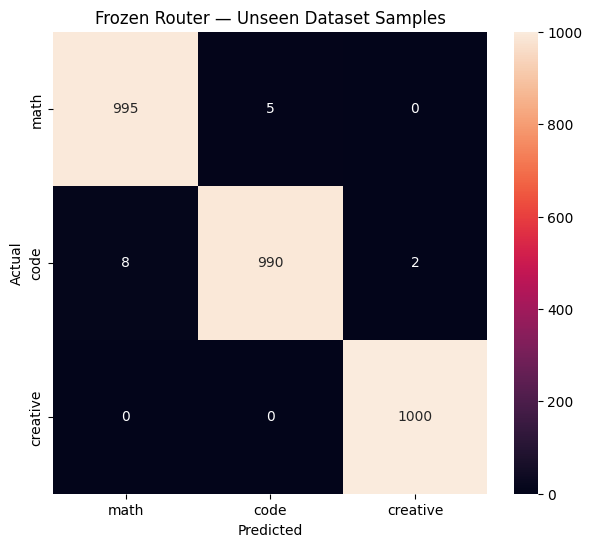

In [45]:
# ============================================================
# Cell 11 — Confusion matrix
# ============================================================

labels = ["math", "code", "creative"]

cm = confusion_matrix(
    unseen_test_df["actual"],
    unseen_test_df["predicted"],
    labels=labels
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Frozen Router — Unseen Dataset Samples")

plt.show()

In [46]:
# ============================================================
# Cell 12 — Inspect incorrect predictions
# ============================================================

errors = unseen_test_df[
    unseen_test_df["actual"] !=
    unseen_test_df["predicted"]
].copy()

errors = errors.sort_values(
    "confidence",
    ascending=False
)

print(
    "Total errors:",
    len(errors)
)

errors.head(50)

Total errors: 15


,query,actual,predicted,confidence
1948,"Calculate the value of ""x"" in the equation ""5x - 12 = 8"".",code,math,0.984948
2727,"Compute the maximum amount of money X which can be obtained using three given coins of denomination A, B, and C, where A, B, and C are prime numbers. Find the minimum number of coins required to make a sum of X, considering that you can use each coin multiple times. Additionally, each coin can o...",code,math,0.951443
1588,Move the parentheses to make the expression give the correct answer.\nExpression: 8 / 2 * (2 + 2)\nAnswer: 16,code,math,0.947501
2414,Find the highest common factor of two numbers 8 and 12.,code,math,0.855163
660,What is the value of ``a`` after the following statement?\na = 5\na += 3,code,math,0.849094
1902,What is the corresponding HTML tag for this sentence?\nI am bold,code,creative,0.785324
2582,What is the largest prime factor of the number 885?,code,math,0.775634
1102,"Given a positive integer $n$, it can be shown that every complex number of the form $r+si$, where $r$ and $s$ are integers, can be uniquely expressed in the ""base"" $-n+i$ using the integers $1,2,\ldots,n^2$ as ""digits."" That is, the equation\[r+si=a_m(-n+i)^m+a_{m-1}(-n+i)^{m-1}+\cdots +a_1(-n+i...",math,code,0.772256
965,Describe the purpose of the ``await`` operator in an asynchronous JavaScript function.,code,creative,0.704626
2930,"For the function $f(x)$, it is true that $f(x + y) = f(x) f(y)$ for all real numbers $x$ and $y$. Determine all the possible values of $f(0)$. Please enter all the possible values, separated by commas.",math,code,0.697894


In [47]:
# ============================================================
# Cell 13 — High-confidence mistakes
# ============================================================

high_conf_errors = errors[
    errors["confidence"] >= 0.90
]

print(
    "High-confidence errors:",
    len(high_conf_errors)
)

print(
    "Percentage of all errors:",
    (
        len(high_conf_errors) /
        max(len(errors), 1)
    ) * 100
)

high_conf_errors.head(30)

High-confidence errors: 3
Percentage of all errors: 20.0


,query,actual,predicted,confidence
1948,"Calculate the value of ""x"" in the equation ""5x - 12 = 8"".",code,math,0.984948
2727,"Compute the maximum amount of money X which can be obtained using three given coins of denomination A, B, and C, where A, B, and C are prime numbers. Find the minimum number of coins required to make a sum of X, considering that you can use each coin multiple times. Additionally, each coin can o...",code,math,0.951443
1588,Move the parentheses to make the expression give the correct answer.\nExpression: 8 / 2 * (2 + 2)\nAnswer: 16,code,math,0.947501


In [48]:
# ============================================================
# Cell 14 — Compare original and unseen evaluation
# ============================================================

original_accuracy = accuracy
original_f1 = macro_f1

print("=" * 60)
print("ROUTER GENERALIZATION CHECK")
print("=" * 60)

print(
    f"Original split accuracy : "
    f"{original_accuracy * 100:.2f}%"
)

print(
    f"Unseen data accuracy    : "
    f"{unseen_accuracy * 100:.2f}%"
)

print()

print(
    f"Original split F1       : "
    f"{original_f1 * 100:.2f}%"
)

print(
    f"Unseen data F1          : "
    f"{unseen_f1 * 100:.2f}%"
)

print()

print(
    f"Accuracy difference     : "
    f"{(original_accuracy - unseen_accuracy) * 100:.2f} percentage points"
)

ROUTER GENERALIZATION CHECK
Original split accuracy : 99.20%
Unseen data accuracy    : 99.50%

Original split F1       : 99.20%
Unseen data F1          : 99.50%

Accuracy difference     : -0.30 percentage points
